# Phylogenetic Exploration — PEP725 Fruit Trees

Explores the phylogenetic relationships among the fruit tree and shrub species in the PEP725 dataset, and asks whether **more closely related species also share similar flowering phenology**.

The analysis uses `PhylogenyFeatures`, which:
1. Resolves scientific names via the **OpenTree TNRS** API
2. Fetches the **induced phylogenetic subtree** from OpenTree
3. Computes an **all-pairs patristic distance matrix** from the Newick tree
4. Embeds species in 2D via **classical MDS**

> **Requires internet access** for the OpenTree API calls in §4.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.cluster import hierarchy as sch
from scipy.spatial.distance import squareform

from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.phylogeny import PhylogenyFeatures
from pysephone.constants import KEY_DATA_SOURCE, KEY_SPECIES_ID, KEY_OBSERVATIONS, KEY_OBS_TYPE

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. Load dataset

We use `PEP725_fruit_trees`, the full fruit-tree subset of PEP725, covering nine well-represented species.

In [2]:
# No calendar or feature providers needed — we work directly with observation dates
obs = Dataset.load('PEP725_fruit_trees').observations

print(f'Total samples (unique loc/year/species/subgroup): {len(obs)}')
print(f'Observation types: {sorted(obs.observation_types)}')
print(f'Species (src, id): {sorted(obs.species_names.keys())}')
print()
print('Species names:')
for key, name in sorted(obs.species_names.items()):
    print(f'  {key[1]:>4d}  {name}')


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 47687.46it/s]


Total samples (unique loc/year/species/subgroup): 40317
Observation types: ['BBCH_60']
Species (src, id): [('pep725', 107), ('pep725', 123), ('pep725', 202), ('pep725', 205), ('pep725', 220), ('pep725', 222), ('pep725', 225), ('pep725', 227), ('pep725', 782)]

Species names:
   107  Corylus avellana
   123  Prunus spinosa
   202  Prunus persica
   205  Prunus armeniaca
   220  Malus x domestica
   222  Prunus avium
   225  Prunus domestica
   227  Pyrus communis
   782  Prunus amygdalis


## 2. Flowering phenology overview

Extract first-bloom observations (`BBCH_60`) and compute day-of-year statistics per species.

In [3]:
TARGET_OBS = 'BBCH_60'   # first bloom

# Pull observations DataFrame and filter to bloom
df_raw = obs._df_y.copy()
df_bloom = df_raw.xs(TARGET_OBS, level=KEY_OBS_TYPE).copy()
df_bloom['doy'] = df_bloom[KEY_OBSERVATIONS].dt.dayofyear
df_bloom = df_bloom.reset_index()

# Attach species names
df_bloom['species_name'] = df_bloom[KEY_SPECIES_ID].map(
    {sid: name for (src, sid), name in obs.species_names.items()}
)

# --- Paired site-year table ---------------------------------------------------
# For each (src, loc_id, year), compute the median bloom DOY per species.
# Multiple subgroups (cultivars) of the same species at the same site/year are
# collapsed to a single value. This table is used for the phylogenetic-signal
# analysis where we need comparable observations at the *same context*.
df_site_year = (
    df_bloom
    .groupby(['src', 'loc_id', 'year', 'species_name'])['doy']
    .median()
    .reset_index()
)
print(f'Bloom observations: {len(df_bloom)} rows')
print(f'Site-year records:  {len(df_site_year)} rows  (one per species × loc × year)')

summary = (
    df_bloom.groupby('species_name')['doy']
    .agg(n='count', mean='mean', std='std', q25=lambda x: x.quantile(0.25),
         median='median', q75=lambda x: x.quantile(0.75))
    .round(1)
    .sort_values('median')
)
print()
print(summary.to_string())

Bloom observations: 40317 rows
Site-year records:  40317 rows  (one per species × loc × year)

                      n   mean   std    q25  median    q75
species_name                                              
Prunus amygdalis    153   41.7  14.9   30.0    41.0   54.0
Corylus avellana   9930   52.6  22.6   35.0    51.0   69.0
Prunus armeniaca    190   92.5  14.1   82.0    91.0  104.0
Prunus spinosa     8337  101.2  14.2   92.0   103.0  112.0
Prunus persica      993  103.9  16.1   90.0   107.0  119.0
Prunus avium       7565  109.2   9.0  103.0   110.0  115.0
Pyrus communis     3284  111.4  10.5  104.0   112.0  119.0
Prunus domestica   3104  114.0  12.8  105.0   116.0  124.0
Malus x domestica  6761  119.0   8.4  114.0   119.0  125.0


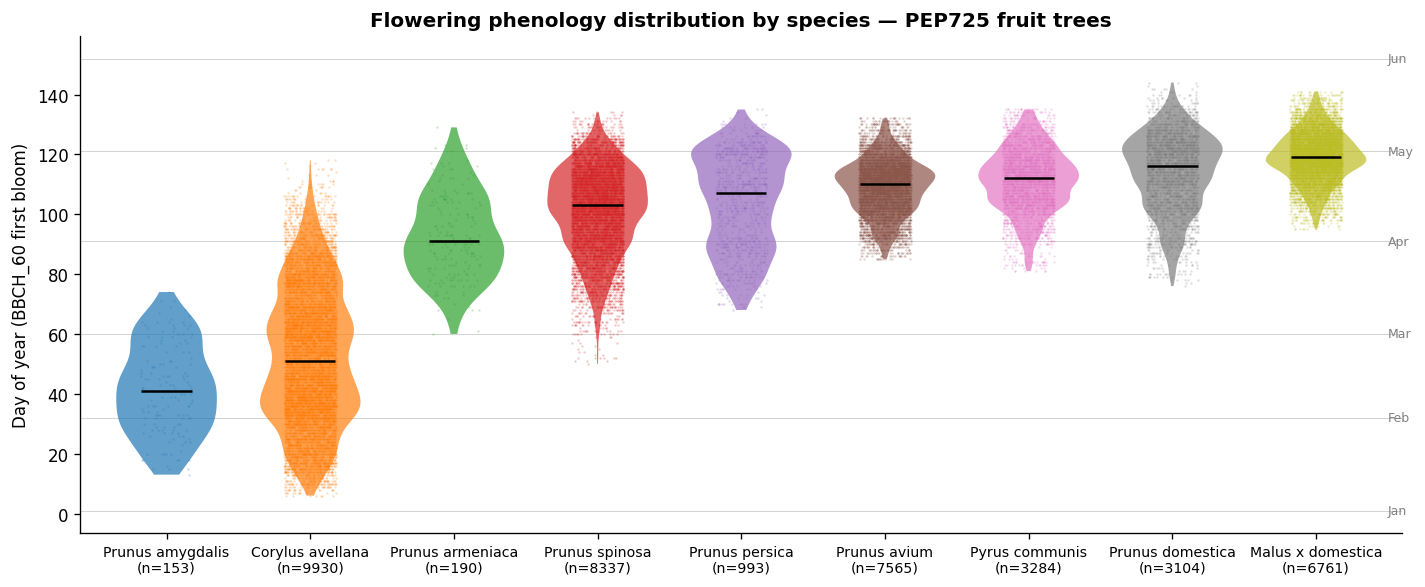

In [4]:
# Colour palette — one colour per species, ordered by median bloom DOY
species_order = summary.index.tolist()
palette = dict(zip(species_order, sns.color_palette('tab10', len(species_order))))

# DOY → approximate month label for axis
_DOY_MONTH = [(1,'Jan'),(32,'Feb'),(60,'Mar'),(91,'Apr'),(121,'May'),(152,'Jun')]

fig, ax = plt.subplots(figsize=(12, 5))

parts = ax.violinplot(
    [df_bloom.loc[df_bloom['species_name'] == sp, 'doy'].values for sp in species_order],
    positions=range(len(species_order)),
    widths=0.7,
    showmedians=True,
    showextrema=False,
)
for i, (pc, sp) in enumerate(zip(parts['bodies'], species_order)):
    pc.set_facecolor(palette[sp])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)

# Overlay individual points (jittered)
rng = np.random.default_rng(0)
for i, sp in enumerate(species_order):
    doys = df_bloom.loc[df_bloom['species_name'] == sp, 'doy'].values
    jitter = rng.uniform(-0.18, 0.18, len(doys))
    ax.scatter(i + jitter, doys, s=2, color=palette[sp], alpha=0.25, linewidths=0)

ax.set_xticks(range(len(species_order)))
ax.set_xticklabels([f'{sp}\n(n={summary.loc[sp,"n"]:.0f})' for sp in species_order],
                   fontsize=8.5)
ax.set_ylabel('Day of year (BBCH_60 first bloom)', fontsize=10)
ax.set_title('Flowering phenology distribution by species — PEP725 fruit trees', fontsize=12, fontweight='bold')

for doy, month in _DOY_MONTH:
    ax.axhline(doy, color='lightgrey', lw=0.6, zorder=0)
    ax.text(len(species_order) - 0.5, doy, month, fontsize=7.5, va='center', color='grey')

ax.set_xlim(-0.6, len(species_order) - 0.4)
plt.tight_layout()
plt.show()

## 3. Temporal trends per species

Mean bloom DOY per species per decade — do species track each other over time?

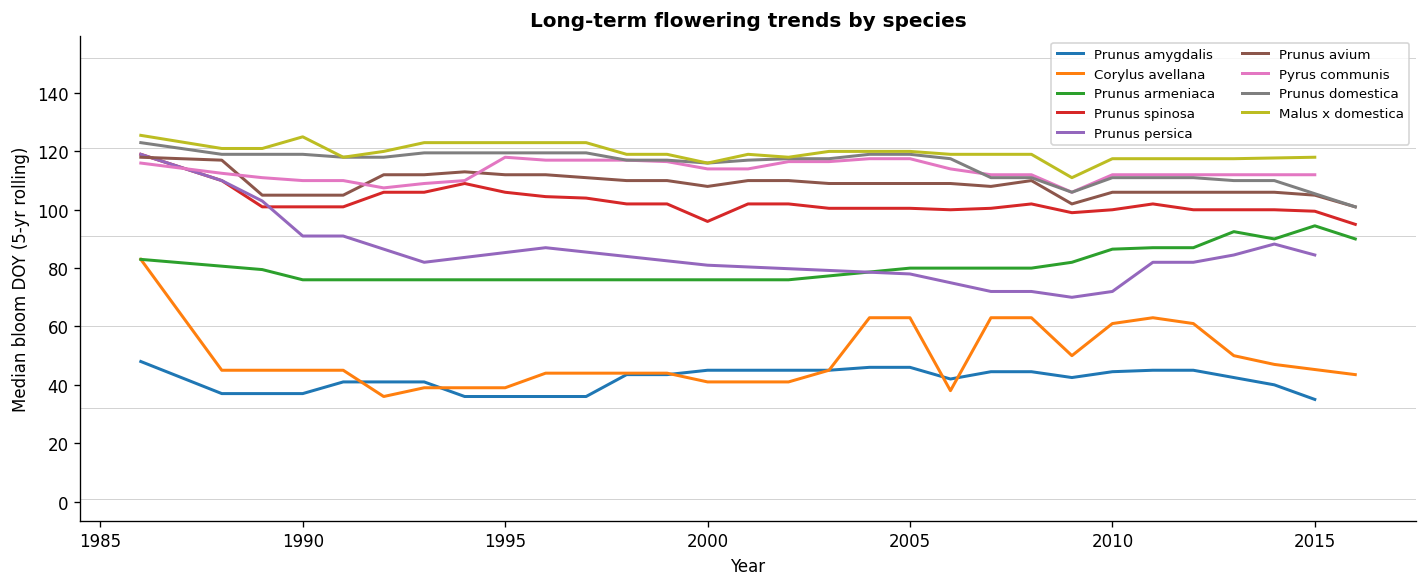

In [5]:
df_bloom['year'] = df_bloom['year'].astype(int)

fig, ax = plt.subplots(figsize=(12, 5))

for sp in species_order:
    sub = df_bloom[df_bloom['species_name'] == sp].copy()
    annual = sub.groupby('year')['doy'].median()
    # Rolling 5-year median
    rolled = annual.rolling(5, center=True, min_periods=2).median()
    ax.plot(rolled.index, rolled.values, color=palette[sp], lw=1.8, label=sp)

ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Median bloom DOY (5-yr rolling)', fontsize=10)
ax.set_title('Long-term flowering trends by species', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.8, ncols=2)

for doy, month in _DOY_MONTH:
    ax.axhline(doy, color='lightgrey', lw=0.6, zorder=0)

plt.tight_layout()
plt.show()

## 4. Fit phylogenetic embedding

`PhylogenyFeatures.fit()` makes two network calls:
1. **TNRS** — resolve scientific names to OpenTree taxon IDs
2. **induced_subtree** — fetch the Newick string for the matched taxa

The patristic distance matrix and MDS coordinates are then computed locally.

In [6]:
phylo = PhylogenyFeatures(k_embed=16, output=['mds', 'distances'])

with warnings.catch_warnings(record=True) as captured:
    warnings.simplefilter('always')
    phylo.fit(obs)

if captured:
    print('Warnings during fit:')
    for w in captured:
        print(' ', str(w.message))

# Build a clean label mapping: species_key → short display name
labels = {k: obs.species_names[k] for k in phylo.species_keys}
label_list = [labels[k] for k in phylo.species_keys]   # same order as distance matrix

print('\nResolved species (in distance matrix order):')
for i, (k, name) in enumerate(zip(phylo.species_keys, label_list)):
    print(f'  [{i}]  species_id={k[1]:>3d}  {name}')

Warnings during fit:
  PhylogenyFeatures: approximate match for 'Prunus amygdalis' → 'Prunus amygdalus'

Resolved species (in distance matrix order):
  [0]  species_id=107  Corylus avellana
  [1]  species_id=123  Prunus spinosa
  [2]  species_id=202  Prunus persica
  [3]  species_id=205  Prunus armeniaca
  [4]  species_id=220  Malus x domestica
  [5]  species_id=222  Prunus avium
  [6]  species_id=225  Prunus domestica
  [7]  species_id=227  Pyrus communis
  [8]  species_id=782  Prunus amygdalis


## 5. Patristic distance matrix

Heatmap of branch-length distances from the OpenTree induced subtree.
Shorter distance = more closely related.

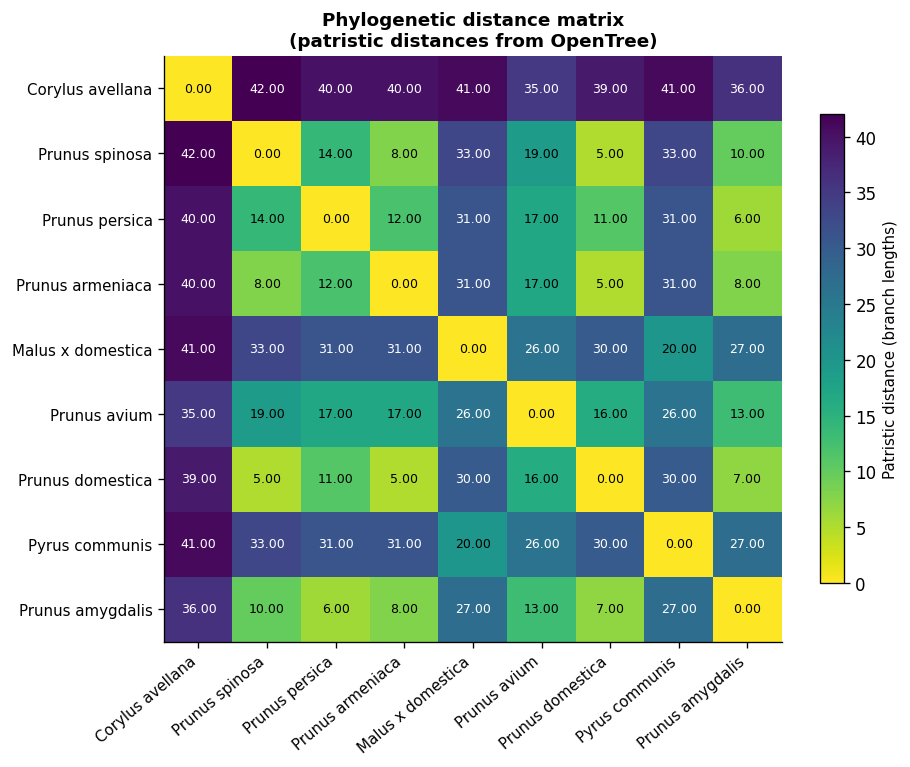

In [7]:
D = phylo.distance_matrix
n_sp = len(label_list)

fig, ax = plt.subplots(figsize=(8, 6.5))

# Normalise for colour mapping; zero diagonal is white
D_plot = D.copy()
mask = np.eye(n_sp, dtype=bool)

im = ax.imshow(D_plot, cmap='viridis_r', aspect='auto')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Patristic distance (branch lengths)', fontsize=9)

ax.set_xticks(range(n_sp))
ax.set_yticks(range(n_sp))
ax.set_xticklabels(label_list, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(label_list, fontsize=9)

# Annotate cells with values
for i in range(n_sp):
    for j in range(n_sp):
        val = D[i, j]
        text_color = 'white' if val > D.max() * 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7.5, color=text_color)

ax.set_title('Phylogenetic distance matrix\n(patristic distances from OpenTree)', 
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Dendrogram from distance matrix

UPGMA clustering of the patristic distance matrix — this approximates the
phylogenetic tree topology from the pairwise distances.

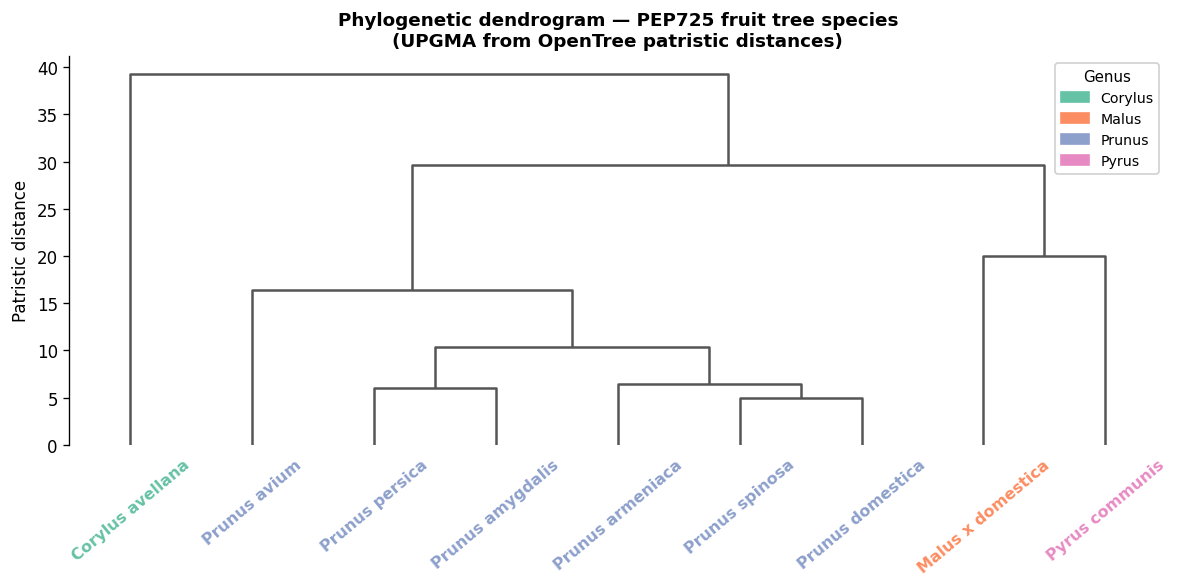

In [8]:
# Condensed distance vector for scipy
condensed = squareform(D, checks=False)
linkage = sch.linkage(condensed, method='average')   # UPGMA

# Colours: one per genus
def _genus(name):
    return name.split()[0]

genera = sorted(set(_genus(n) for n in label_list))
genus_colors = dict(zip(genera, sns.color_palette('Set2', len(genera))))
leaf_colors = [genus_colors[_genus(n)] for n in label_list]

fig, ax = plt.subplots(figsize=(10, 5))

dend = sch.dendrogram(
    linkage,
    labels=label_list,
    leaf_rotation=40,
    leaf_font_size=9.5,
    ax=ax,
    color_threshold=0,    # disable automatic colouring
    above_threshold_color='#555555',
)

# Colour the leaf labels by genus
xlbls = ax.get_xmajorticklabels()
for lbl in xlbls:
    genus = _genus(lbl.get_text())
    lbl.set_color(genus_colors.get(genus, 'black'))
    lbl.set_fontweight('semibold')

ax.set_ylabel('Patristic distance', fontsize=10)
ax.set_title('Phylogenetic dendrogram — PEP725 fruit tree species\n(UPGMA from OpenTree patristic distances)',
             fontsize=11, fontweight='bold')

# Genus legend
patches = [mpatches.Patch(color=c, label=g) for g, c in genus_colors.items()]
ax.legend(handles=patches, title='Genus', fontsize=8.5, title_fontsize=9,
          loc='upper right', framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.tight_layout()
plt.show()

## 7. MDS embedding — all dimensions

Classical MDS embeds the distance matrix into `k_actual = min(k_embed, n_species − 1)` dimensions. The scatter-matrix below shows all pairs of MDS axes; the diagonal reports variance explained by that axis.

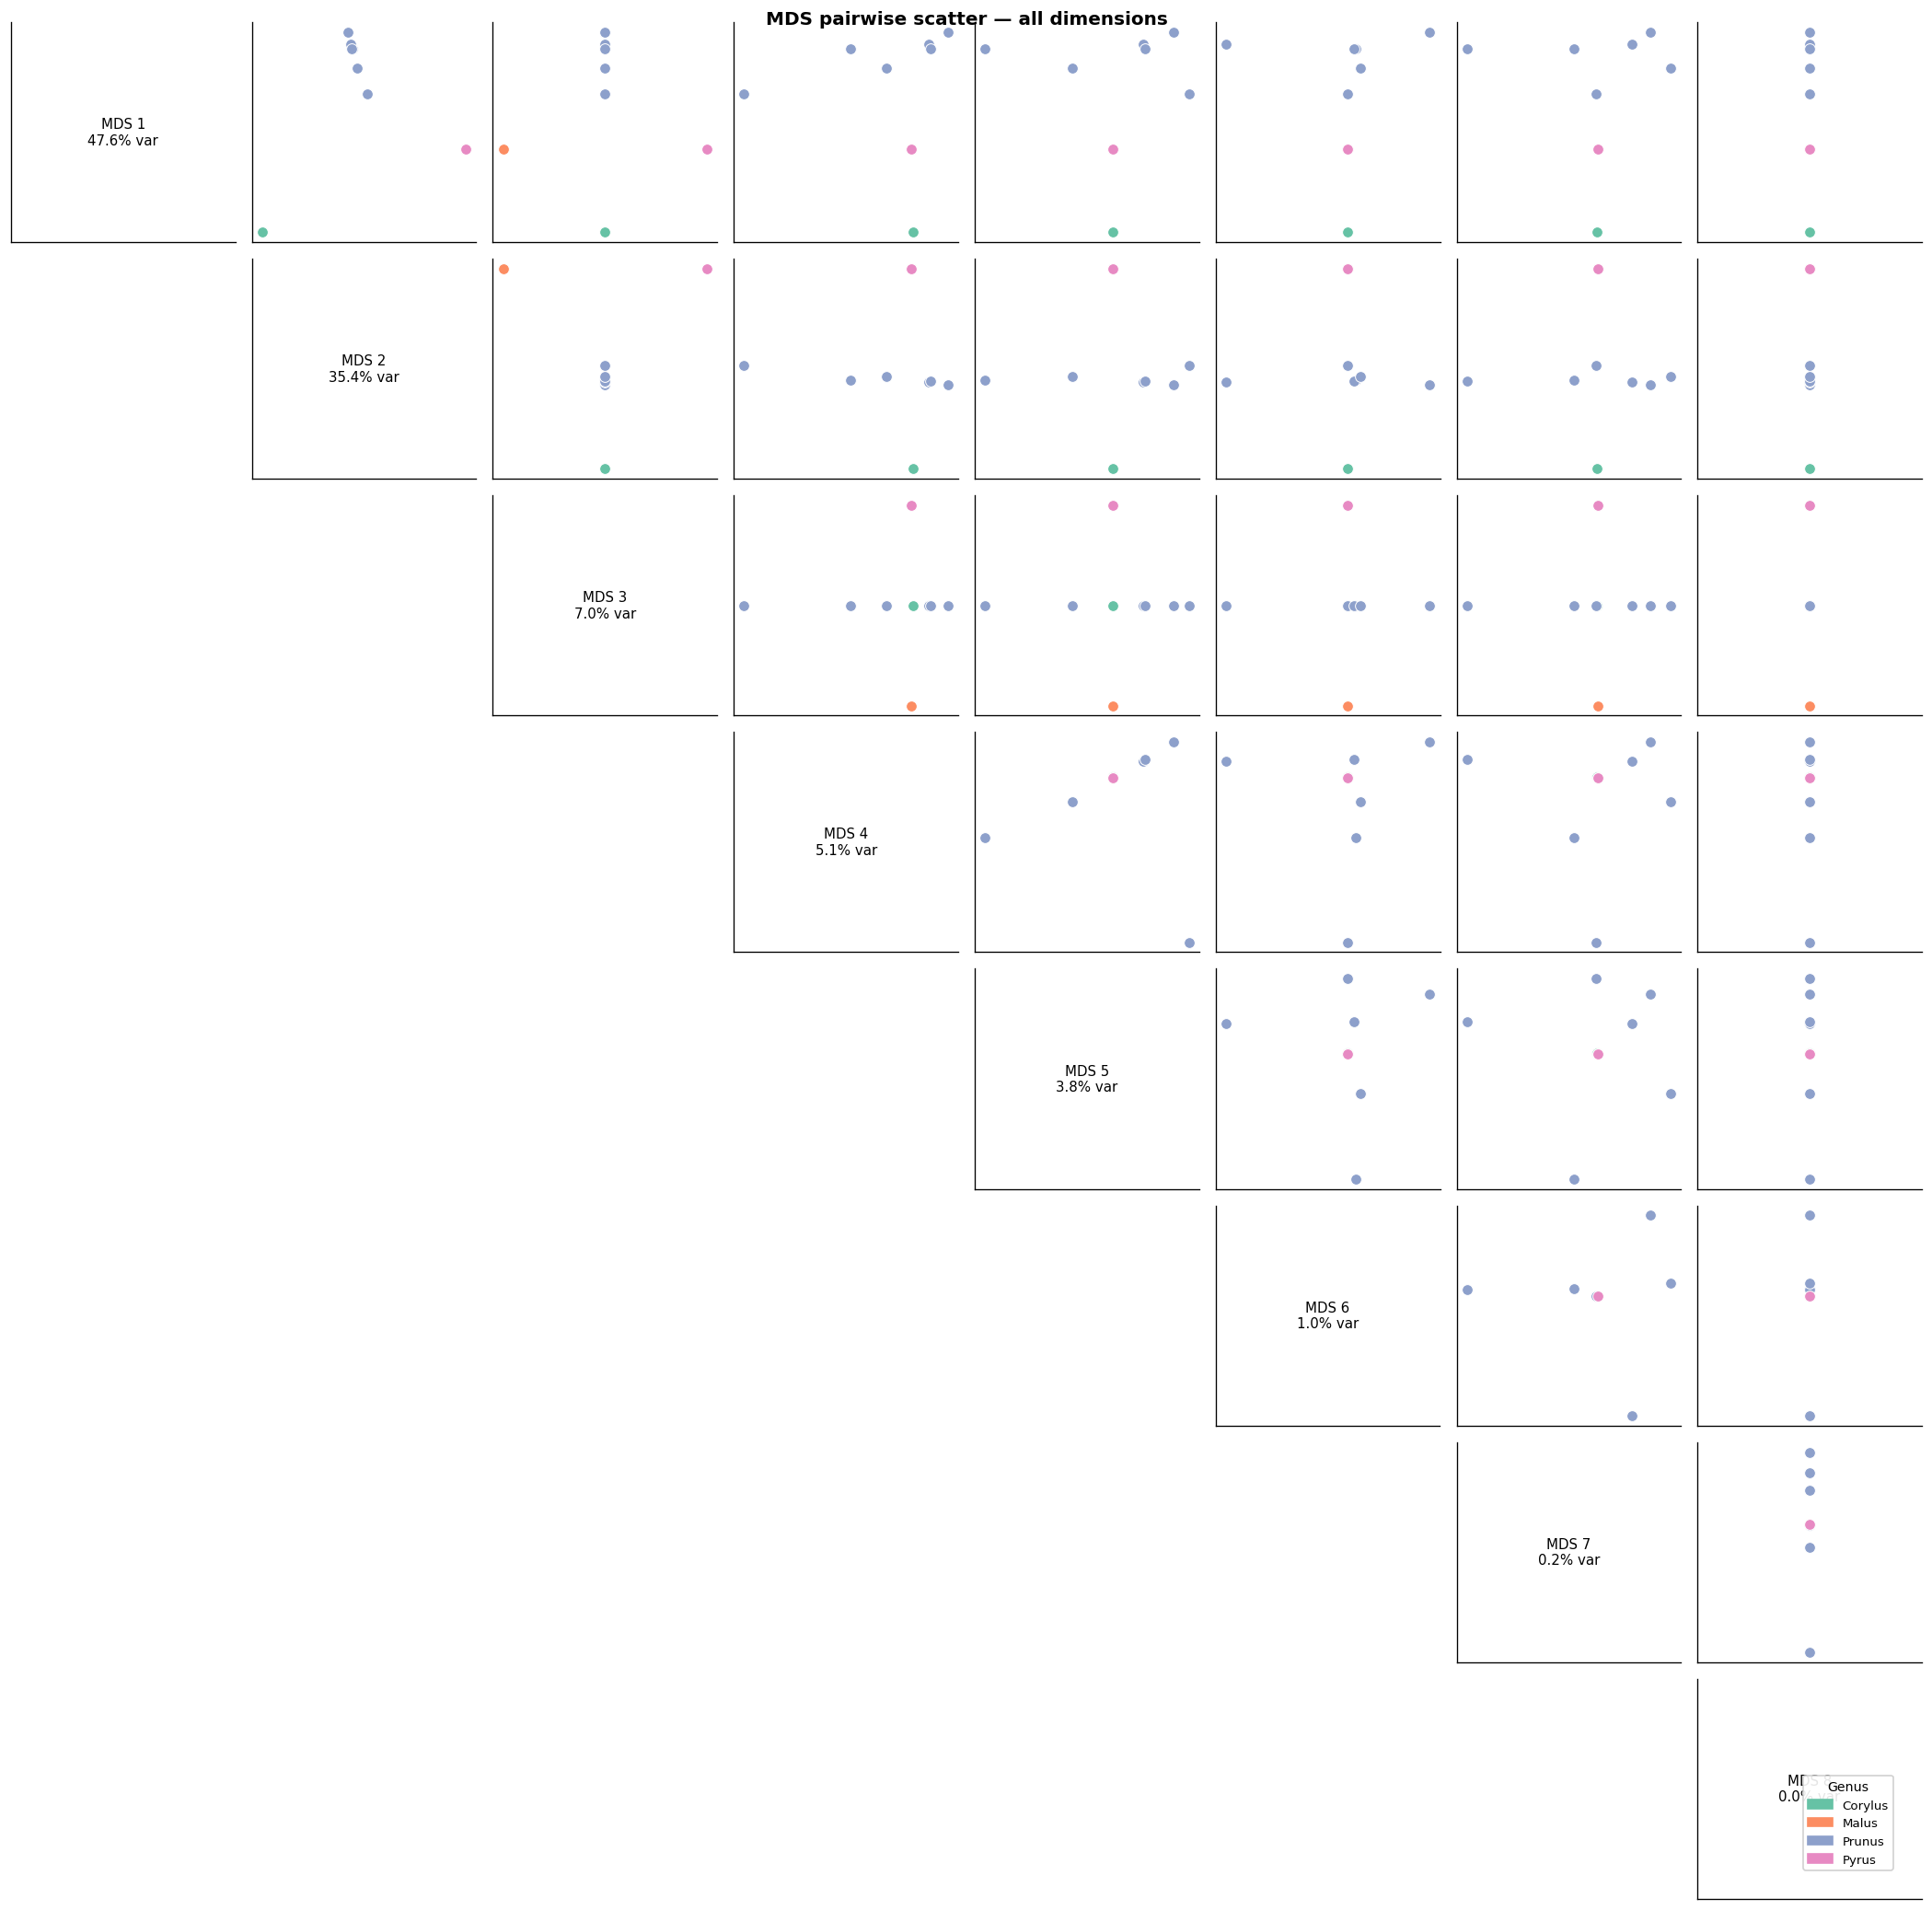

In [9]:
coords = phylo.mds_coords      # (N, k_actual)
k_actual = coords.shape[1]

# Eigenspectrum for variance labels
D2 = D ** 2
n  = D.shape[0]
H  = np.eye(n) - np.ones((n, n)) / n
B  = -0.5 * H @ D2 @ H
B  = (B + B.T) / 2
evals      = np.linalg.eigvalsh(B)
evals_pos  = np.maximum(evals, 0.0)
evals_sort = np.sort(evals_pos)[::-1]
var_per_dim = evals_sort[:k_actual] / evals_sort.sum() * 100

fig, axes = plt.subplots(k_actual, k_actual,
                         figsize=(2.2 * k_actual, 2.2 * k_actual),
                         squeeze=False)
fig.suptitle('MDS pairwise scatter — all dimensions', fontsize=12, fontweight='bold')

for row in range(k_actual):
    for col in range(k_actual):
        ax = axes[row][col]
        if row == col:
            ax.text(0.5, 0.5,
                    f'MDS {row+1}\n{var_per_dim[row]:.1f}% var',
                    ha='center', va='center', fontsize=9,
                    transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
        elif col > row:  # upper triangle: scatter
            for name, pt in zip(label_list, coords):
                genus = _genus(name)
                ax.scatter(pt[col], pt[row], s=50,
                           color=genus_colors[genus],
                           edgecolors='white', linewidths=0.6, zorder=3)
            ax.set_xticks([]); ax.set_yticks([])
        else:            # lower triangle: blank
            ax.set_visible(False)

# Genus legend
patches = [mpatches.Patch(color=c, label=g) for g, c in genus_colors.items()]
fig.legend(handles=patches, title='Genus', fontsize=8, title_fontsize=8.5,
           loc='lower right', bbox_to_anchor=(0.98, 0.02), framealpha=0.9)
plt.tight_layout()
plt.show()


## 7b. MDS quality — eigenspectrum, stress, and Shepard diagram

Three complementary diagnostics for the MDS reconstruction:

- **Eigenspectrum + cumulative variance**: how many dimensions capture most variation
- **Stress-1 (Kruskal)**: `sqrt(Σ(d−d̂)² / Σd²)` — lower is better (<0.1 is good)
- **Shepard diagram**: scatter of true vs reconstructed pairwise distances

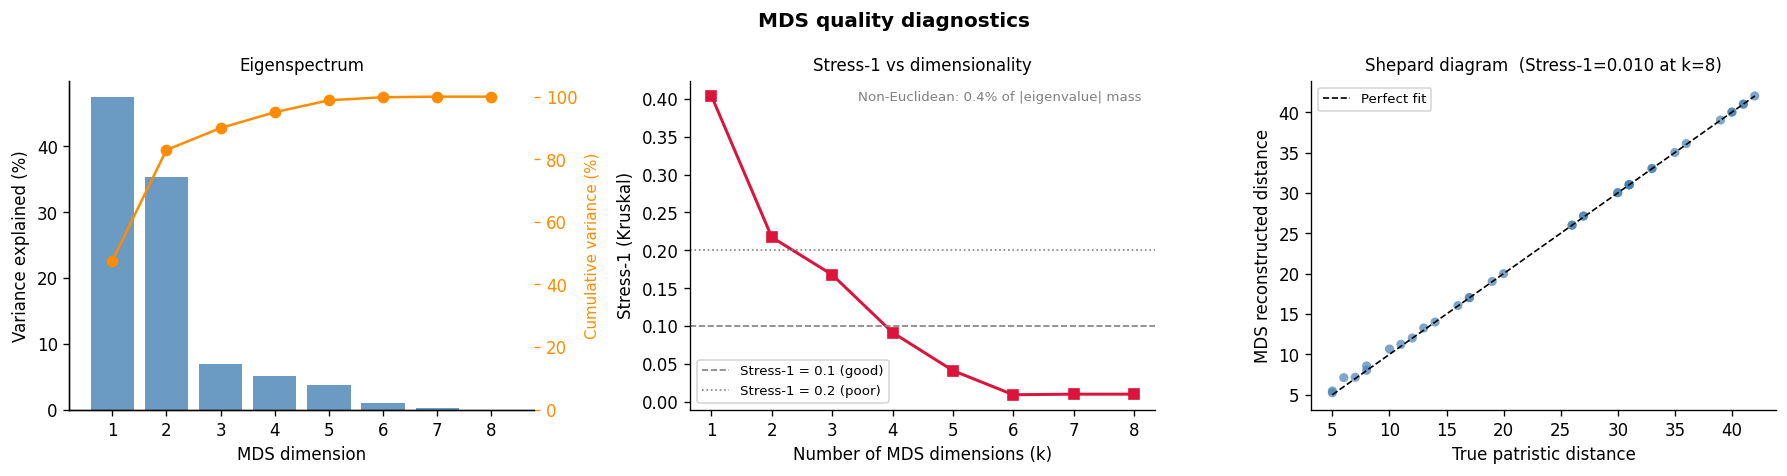

Variance explained by first 2 dims: 83.0%
Variance explained by all 8 dims: 100.0%
Stress-1 at k=2: 0.217
Stress-1 at k=8: 0.010


In [10]:
# ── Eigenspectrum ────────────────────────────────────────────────────────
cumvar = np.cumsum(evals_sort) / evals_sort.sum() * 100
n_neg  = (evals < 0).sum()
frac_neg = (-np.minimum(evals, 0)).sum() / np.abs(evals).sum() * 100

# Stress-1 at each k
idx_upper = np.triu_indices(n, k=1)
d_true    = D[idx_upper]

def stress1(coords_k):
    from scipy.spatial.distance import pdist
    d_hat = pdist(coords_k)
    return np.sqrt(((d_true - d_hat)**2).sum() / (d_true**2).sum())

stress_vals = [stress1(coords[:, :k]) for k in range(1, k_actual + 1)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('MDS quality diagnostics', fontsize=12, fontweight='bold')

# Left: eigenspectrum
ax = axes[0]
ax.bar(range(1, k_actual + 1), var_per_dim, color='steelblue', alpha=0.8)
ax2 = ax.twinx()
ax2.plot(range(1, k_actual + 1), cumvar[:k_actual], 'o-', color='darkorange', lw=1.5)
ax2.set_ylabel('Cumulative variance (%)', color='darkorange', fontsize=9)
ax2.tick_params(axis='y', colors='darkorange')
ax2.set_ylim(0, 105)
ax.set_xlabel('MDS dimension', fontsize=10)
ax.set_ylabel('Variance explained (%)', fontsize=10)
ax.set_title('Eigenspectrum', fontsize=10)
ax.set_xticks(range(1, k_actual + 1))

# Middle: Stress-1 curve
ax = axes[1]
ax.plot(range(1, k_actual + 1), stress_vals, 's-', color='crimson', lw=1.8)
ax.axhline(0.1, color='grey', ls='--', lw=1, label='Stress-1 = 0.1 (good)')
ax.axhline(0.2, color='grey', ls=':', lw=1, label='Stress-1 = 0.2 (poor)')
ax.set_xlabel('Number of MDS dimensions (k)', fontsize=10)
ax.set_ylabel('Stress-1 (Kruskal)', fontsize=10)
ax.set_title('Stress-1 vs dimensionality', fontsize=10)
ax.set_xticks(range(1, k_actual + 1))
ax.legend(fontsize=8)
ax.text(0.97, 0.97,
        f'Non-Euclidean: {frac_neg:.1f}% of |eigenvalue| mass',
        ha='right', va='top', transform=ax.transAxes, fontsize=8, color='grey')

# Right: Shepard diagram (all dims)
ax = axes[2]
from scipy.spatial.distance import pdist
d_hat_full = pdist(coords)
ax.scatter(d_true, d_hat_full, s=30, alpha=0.7, color='steelblue', edgecolors='none')
mn, mx = min(d_true.min(), d_hat_full.min()), max(d_true.max(), d_hat_full.max())
ax.plot([mn, mx], [mn, mx], 'k--', lw=1, label='Perfect fit')
ax.set_xlabel('True patristic distance', fontsize=10)
ax.set_ylabel('MDS reconstructed distance', fontsize=10)
ax.set_title(f'Shepard diagram  (Stress-1={stress_vals[-1]:.3f} at k={k_actual})', fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f'Variance explained by first 2 dims: {cumvar[1]:.1f}%')
print(f'Variance explained by all {k_actual} dims: {cumvar[k_actual-1]:.1f}%')
print(f'Stress-1 at k=2: {stress_vals[1]:.3f}')
print(f'Stress-1 at k={k_actual}: {stress_vals[-1]:.3f}')


## 8. Phylogenetic signal in phenology

Is there a **phylogenetic signal** in bloom timing?

Naively comparing species mean bloom DOY is misleading: species A might flower
earlier than species B simply because it is measured at warmer sites or in warmer
years — not because it is inherently earlier.

The correct comparison uses **paired observations**: for every (location, year)
where *both* species have a bloom record, compute the difference in DOY.
Averaging these paired differences removes shared climate variation and isolates
the species-level phenological offset.

We then plot this mean paired |ΔDOY| against phylogenetic distance.

  Corylus avellana               vs Prunus spinosa                  |ΔDOY|= 51.9 d  n=6211  phylo=42.00
  Corylus avellana               vs Prunus persica                  |ΔDOY|= 48.6 d  n= 280  phylo=40.00
  Corylus avellana               vs Prunus armeniaca                |ΔDOY|= 34.9 d  n=  90  phylo=40.00
  Corylus avellana               vs Malus x domestica               |ΔDOY|= 67.6 d  n=4950  phylo=41.00
  Corylus avellana               vs Prunus avium                    |ΔDOY|= 55.2 d  n=4375  phylo=35.00
  Corylus avellana               vs Prunus domestica                |ΔDOY|= 50.2 d  n=2024  phylo=39.00
  Corylus avellana               vs Pyrus communis                  |ΔDOY|= 57.7 d  n=2026  phylo=41.00
  Corylus avellana               vs Prunus amygdalis                |ΔDOY|= 16.6 d  n=  54  phylo=36.00
  Prunus spinosa                 vs Prunus persica                  |ΔDOY|=  4.2 d  n= 268  phylo=14.00
  Prunus spinosa                 vs Prunus armeniaca            

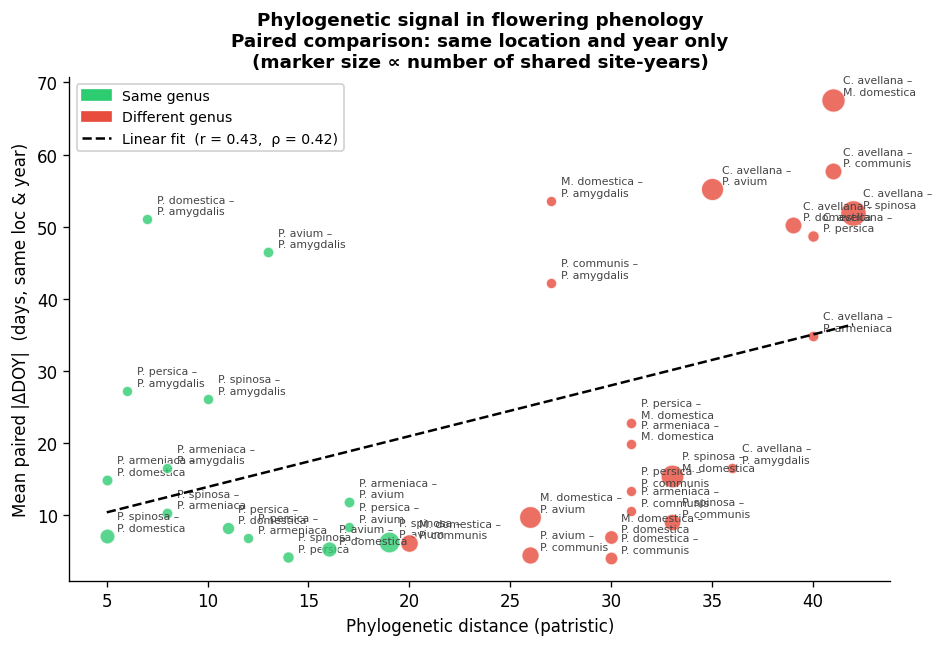

In [11]:
def _rankdata(x):
    """Rank values (average ties), returning floats."""
    tmp = np.argsort(x)
    ranks = np.empty_like(tmp, dtype=float)
    ranks[tmp] = np.arange(1, len(x) + 1)
    _, inv, counts = np.unique(x, return_inverse=True, return_counts=True)
    for i, c in enumerate(counts):
        if c > 1:
            ranks[inv == i] = ranks[inv == i].mean()
    return ranks


def paired_pheno_diff(df_sy, sp_i, sp_j):
    """Mean absolute DOY difference at shared (loc, year) contexts."""
    idx = ['src', 'loc_id', 'year']
    sub_i = df_sy[df_sy['species_name'] == sp_i].set_index(idx)['doy']
    sub_j = df_sy[df_sy['species_name'] == sp_j].set_index(idx)['doy']
    joined = sub_i.to_frame('i').join(sub_j.to_frame('j'), how='inner')
    if joined.empty:
        return np.nan, 0
    return (joined['i'] - joined['j']).abs().mean(), len(joined)


phylo_dist_pairs = []
pheno_dist_pairs = []
n_pairs_list     = []
pair_labels      = []

for i in range(n_sp):
    for j in range(i + 1, n_sp):
        sp_i, sp_j = label_list[i], label_list[j]
        pheno_d, n_paired = paired_pheno_diff(df_site_year, sp_i, sp_j)
        if np.isnan(pheno_d) or np.isnan(D[i, j]):
            continue
        phylo_dist_pairs.append(D[i, j])
        pheno_dist_pairs.append(pheno_d)
        n_pairs_list.append(n_paired)
        pair_labels.append((sp_i, sp_j))
        print(f'  {sp_i:30s} vs {sp_j:30s}  |ΔDOY|={pheno_d:5.1f} d  n={n_paired:4d}  phylo={D[i,j]:.2f}')

phylo_dist_pairs = np.array(phylo_dist_pairs)
pheno_dist_pairs = np.array(pheno_dist_pairs)
n_pairs_arr      = np.array(n_pairs_list)

# Pearson r and Spearman ρ on the raw vectors (not permutation-corrected)
r_pearson  = np.corrcoef(phylo_dist_pairs, pheno_dist_pairs)[0, 1]
r_spearman = np.corrcoef(_rankdata(phylo_dist_pairs), _rankdata(pheno_dist_pairs))[0, 1]
print(f'\nPearson r  = {r_pearson:.3f}')
print(f'Spearman ρ = {r_spearman:.3f}')
print('(Permutation p-values in §8b)')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))

for (sp_i, sp_j), pd_val, pheno_d, n in zip(
        pair_labels, phylo_dist_pairs, pheno_dist_pairs, n_pairs_arr):
    same_genus = _genus(sp_i) == _genus(sp_j)
    color = '#2ecc71' if same_genus else '#e74c3c'
    size  = 40 + n / n_pairs_arr.max() * 200
    ax.scatter(pd_val, pheno_d, color=color, s=size, alpha=0.80,
               edgecolors='white', linewidths=0.8, zorder=3)
    ax.annotate(
        f'{sp_i.split()[0][0]}. {sp_i.split()[-1]} –\n'
        f'{sp_j.split()[0][0]}. {sp_j.split()[-1]}',
        (pd_val, pheno_d), xytext=(6, 3), textcoords='offset points',
        fontsize=6.5, color='#444444',
    )

m_coef = np.polyfit(phylo_dist_pairs, pheno_dist_pairs, 1)
x_line = np.linspace(phylo_dist_pairs.min(), phylo_dist_pairs.max(), 100)
ax.plot(x_line, np.polyval(m_coef, x_line),
        color='black', lw=1.5, ls='--', zorder=4,
        label=f'Linear fit  (r = {r_pearson:.2f},  ρ = {r_spearman:.2f})')

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='Same genus'),
    mpatches.Patch(color='#e74c3c', label='Different genus'),
]
ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0][-1:],
          fontsize=8.5, framealpha=0.9)

ax.set_xlabel('Phylogenetic distance (patristic)', fontsize=10)
ax.set_ylabel('Mean paired |ΔDOY|  (days, same loc & year)', fontsize=10)
ax.set_title(
    'Phylogenetic signal in flowering phenology\n'
    'Paired comparison: same location and year only\n'
    '(marker size ∝ number of shared site-years)',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()


## 8b. Mantel test — Pearson and Spearman

Standard Pearson significance tests assume **independent observations**, but species-pair distances are not: each species appears in multiple pairs simultaneously.

The **Mantel test** provides a valid p-value by permuting species labels (rows & cols of the distance matrix simultaneously) and recomputing the correlation statistic.

We report both **Pearson r** (tests linearity) and **Spearman ρ** (tests monotonicity — more appropriate for ordinal OpenTree branch-count distances).

Mantel test results:
  Pearson   : stat=0.434  p=0.0886
  Spearman  : stat=0.417  p=0.0895


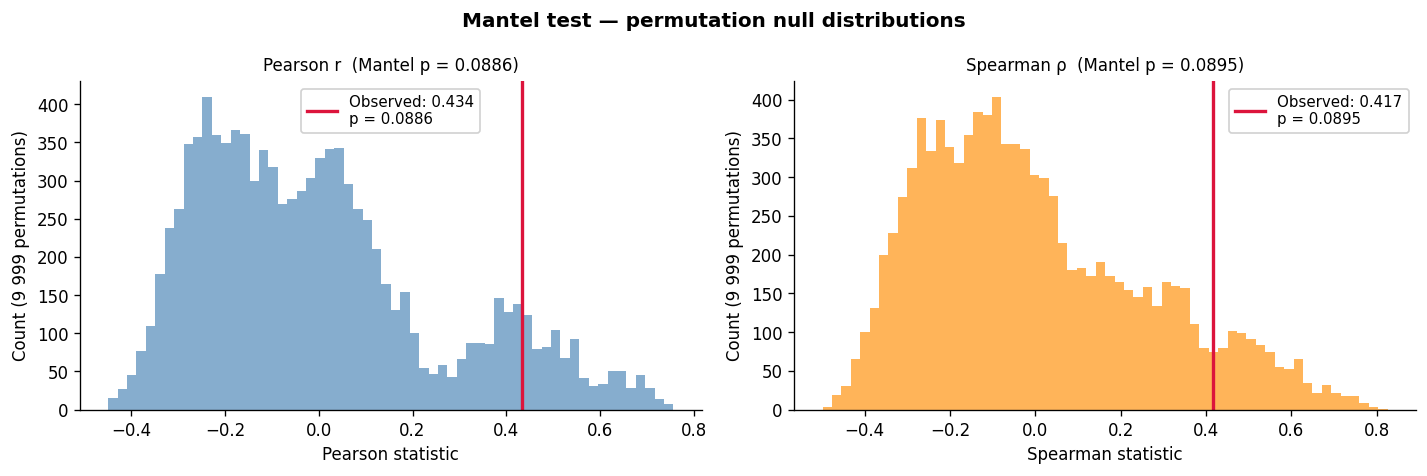

In [12]:
def mantel_test(D_phylo, D_pheno, n_perm=9999, rng_seed=0):
    """
    Mantel test using both Pearson r and Spearman ρ as test statistics.

    Permutes species labels (rows & cols simultaneously) of D_pheno and
    recomputes both correlations against D_phylo each step.

    Returns dict with keys 'pearson' and 'spearman', each containing:
        stat   : observed correlation
        p_val  : one-tailed p (proportion of permuted stats >= observed)
        null   : array of permuted statistics
    """
    n   = D_phylo.shape[0]
    idx = np.triu_indices(n, k=1)
    x   = D_phylo[idx]
    y   = D_pheno[idx]

    xr  = _rankdata(x)
    yr  = _rankdata(y)

    def pearson(a, b):
        a, b = a - a.mean(), b - b.mean()
        denom = np.sqrt((a**2).sum() * (b**2).sum())
        return (a * b).sum() / denom if denom > 0 else 0.0

    r_obs   = pearson(x,  y)
    rho_obs = pearson(xr, yr)

    rng      = np.random.default_rng(rng_seed)
    r_null   = np.empty(n_perm)
    rho_null = np.empty(n_perm)
    for k in range(n_perm):
        perm    = rng.permutation(n)
        D_perm  = D_pheno[np.ix_(perm, perm)]
        yp      = D_perm[idx]
        ypr     = _rankdata(yp)
        r_null[k]   = pearson(x,  yp)
        rho_null[k] = pearson(xr, ypr)

    return {
        'pearson':  {'stat': r_obs,   'p_val': (r_null   >= r_obs).mean(),   'null': r_null},
        'spearman': {'stat': rho_obs, 'p_val': (rho_null >= rho_obs).mean(), 'null': rho_null},
    }


# Build phenological distance matrix
D_pheno = np.full((n_sp, n_sp), np.nan)
for (sp_i, sp_j), phd, n in zip(pair_labels, pheno_dist_pairs, n_pairs_arr):
    i = label_list.index(sp_i)
    j = label_list.index(sp_j)
    D_pheno[i, j] = phd
    D_pheno[j, i] = phd
np.fill_diagonal(D_pheno, 0.0)

# Fill any NaN pairs with max observed distance
max_pheno = np.nanmax(D_pheno)
D_pheno   = np.where(np.isnan(D_pheno), max_pheno, D_pheno)

result = mantel_test(D, D_pheno, n_perm=9999)

print('Mantel test results:')
for key, res in result.items():
    print(f"  {key.capitalize():10s}: stat={res['stat']:.3f}  p={res['p_val']:.4f}")

# ── Plot permutation distributions side-by-side ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Mantel test — permutation null distributions', fontsize=12, fontweight='bold')

for ax, (key, res), color in zip(
        axes,
        result.items(),
        ['steelblue', 'darkorange']):
    stat, p_val, null = res['stat'], res['p_val'], res['null']
    ax.hist(null, bins=60, color=color, alpha=0.65, edgecolor='none')
    ax.axvline(stat, color='crimson', lw=2,
               label=f'Observed: {stat:.3f}\np = {p_val:.4f}')
    ax.set_xlabel(f'{key.capitalize()} statistic', fontsize=10)
    ax.set_ylabel('Count (9 999 permutations)', fontsize=10)
    ax.set_title(
        f'{"Pearson r" if key=="pearson" else "Spearman ρ"}'
        f'  (Mantel p = {p_val:.4f})',
        fontsize=10
    )
    ax.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()


## 9. Clustermap — phenology × phylogeny

Hierarchically-clustered heatmap of species, with rows ordered by phylogenetic
dendrogram and columns representing quantile bins of year.  Shows whether
the phylogenetic ordering also reveals structure in multi-year bloom timing.

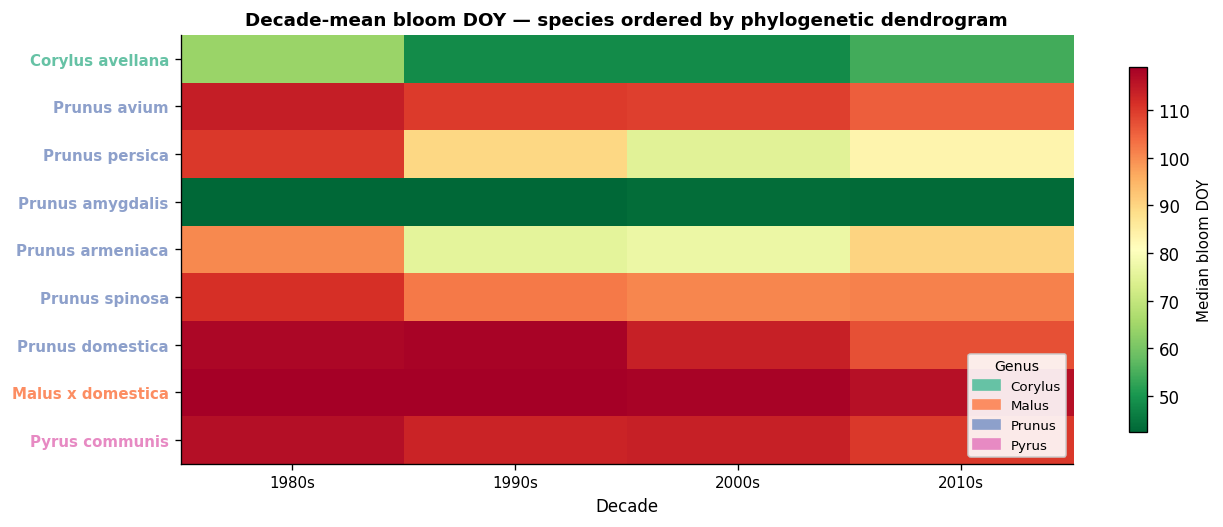

In [13]:
# Annual median bloom DOY per species — only species with enough data
MIN_YEARS = 5
sp_annual = {}
for k, name in labels.items():
    sid = k[1]
    sub = df_bloom[df_bloom[KEY_SPECIES_ID] == sid].copy()
    ann = sub.groupby('year')['doy'].median()
    if len(ann) >= MIN_YEARS:
        sp_annual[name] = ann

all_years = sorted(set(y for ann in sp_annual.values() for y in ann.index))
heat_df = pd.DataFrame(
    {name: ann.reindex(all_years) for name, ann in sp_annual.items()},
    index=all_years,
).T

# Reorder rows by phylogenetic dendrogram (using leaves order from above)
dend_order = [label_list[i] for i in sch.leaves_list(linkage) if label_list[i] in heat_df.index]
heat_df = heat_df.loc[dend_order]

# Decade-averaged for cleaner display
decade_cols = {}
for col in heat_df.columns:
    decade = (col // 10) * 10
    decade_cols.setdefault(decade, []).append(col)
heat_decade = pd.DataFrame(
    {str(d) + 's': heat_df[cols].mean(axis=1) for d, cols in sorted(decade_cols.items())}
)

fig, ax = plt.subplots(figsize=(11, 4.5))

im = ax.imshow(heat_decade.values, cmap='RdYlGn_r', aspect='auto',
               vmin=np.nanpercentile(heat_decade.values, 5),
               vmax=np.nanpercentile(heat_decade.values, 95))
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Median bloom DOY', fontsize=9)

ax.set_yticks(range(len(heat_decade)))
ax.set_yticklabels(heat_decade.index, fontsize=9)
ax.set_xticks(range(len(heat_decade.columns)))
ax.set_xticklabels(heat_decade.columns, fontsize=9)

# Colour y-axis labels by genus
for ylabel_obj in ax.get_yticklabels():
    genus = _genus(ylabel_obj.get_text())
    ylabel_obj.set_color(genus_colors.get(genus, 'black'))
    ylabel_obj.set_fontweight('semibold')

ax.set_title(
    'Decade-mean bloom DOY — species ordered by phylogenetic dendrogram',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Decade', fontsize=10)

# Genus legend on side
patches = [mpatches.Patch(color=c, label=g) for g, c in genus_colors.items()
           if any(_genus(sp) == g for sp in heat_decade.index)]
ax.legend(handles=patches, title='Genus', fontsize=8, title_fontsize=8.5,
          loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show()

## 10. Summary

Key findings from the phylogenetic analysis:

In [14]:
# Summary table: species × (mean bloom DOY, std, phylo cluster, mean paired offset)
cut_height = linkage[-1, 2] * 0.5
cluster_ids = sch.fcluster(linkage, cut_height, criterion='distance')
cluster_map = {name: f'Cluster {c}' for name, c in zip(label_list, cluster_ids)}

# Mean paired offset vs all other species (weighted by n_pairs)
mean_offset = {}
for i, sp_i in enumerate(label_list):
    offsets, weights = [], []
    for j, sp_j in enumerate(label_list):
        if i == j:
            continue
        key = (min(sp_i, sp_j), max(sp_i, sp_j))
        # Look up in pair_labels
        for (a, b), phd, n in zip(pair_labels, pheno_dist_pairs, n_pairs_arr):
            if {a, b} == {sp_i, sp_j}:
                offsets.append(phd)
                weights.append(n)
                break
    if offsets:
        mean_offset[sp_i] = np.average(offsets, weights=weights)
    else:
        mean_offset[sp_i] = np.nan

rows = []
for name in label_list:
    sid = next(k[1] for k, n in labels.items() if n == name)
    doys = df_bloom.loc[df_bloom[KEY_SPECIES_ID] == sid, 'doy'].values
    rows.append({
        'Species': name,
        'Genus': _genus(name),
        'N obs': len(doys),
        'Mean bloom DOY': round(doys.mean(), 1) if len(doys) else float('nan'),
        'Std (days)': round(doys.std(), 1) if len(doys) else float('nan'),
        'Mean paired |ΔDOY|': round(mean_offset.get(name, float('nan')), 1),
        'Phylo cluster': cluster_map[name],
    })

summary_df = pd.DataFrame(rows).set_index('Species').sort_values('Mean bloom DOY')
print(summary_df.to_string())
print(f'\nPearson r (phylo dist vs paired |ΔDOY|): {r_pearson:.3f}')
print('(Paired: same location and year; controls for spatial and temporal climate variation)')

                     Genus  N obs  Mean bloom DOY  Std (days)  Mean paired |ΔDOY| Phylo cluster
Species                                                                                        
Prunus amygdalis    Prunus    153            41.7        14.8                36.4     Cluster 1
Corylus avellana   Corylus   9930            52.6        22.6                56.7     Cluster 4
Prunus armeniaca    Prunus    190            92.5        14.0                17.1     Cluster 1
Prunus spinosa      Prunus   8337           101.2        14.2                24.6     Cluster 1
Prunus persica      Prunus    993           103.9        16.1                17.9     Cluster 1
Prunus avium        Prunus   7565           109.2         9.0                20.4     Cluster 1
Pyrus communis       Pyrus   3284           111.4        10.5                17.8     Cluster 3
Prunus domestica    Prunus   3104           114.0        12.8                19.3     Cluster 1
Malus x domestica    Malus   6761       